# Step 1 (V9): Conservative AI Classifier - Cost-Sensitive Learning (Option 3)

## 🎯 Objective:
Meningkatkan **Presisi (Precision)** dengan menekan jumlah *False Positives* (Prediksi 1 tapi Aktual 0). Kita ingin AI hanya memberikan sinyal Bullish jika benar-benar yakin, karena masuk ke pasar saat harga turun (False Positive) dianggap sebagai 'kesalahan yang sangat mahal'.

## ⚖️ Strategy: Cost-Sensitive Learning
Kita memberikan penalti atau bobot lebih berat pada kelas 0 (Bearish/Neutral). 

**Logikanya:**
- Secara default, model menganggap salah tebak kelas 0 dan kelas 1 memiliki 'biaya' yang sama.
- Di V9 ini, kita mengatur `class_weight={0: 2, 1: 1}` (sebagai contoh).
- Artinya, model akan menganggap **salah mengklasifikasikan hari Bearish sebagai Bullish adalah 'dosa' yang 2 kali lipat lebih besar** daripada sebaliknya.
- Hasilnya, model akan menjadi sangat 'penakut' dan konservatif dalam memberikan label 1.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')

print("✅ Libraries loaded. Starting V9 (Cost-Sensitive Learning)...")

✅ Libraries loaded. Starting V9 (Cost-Sensitive Learning)...


## 1. Data Preparation
Kita tetap gunakan target 5-Day Trend dari V2 sebagai dasar perbandingan.

In [2]:
# Load data
data = pd.read_excel('dataset_2023_2025.xlsx', index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Vol_50'] = market_return.rolling(window=50).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features['Log_Ret'] = market_return

# Target: 5-Day Trend
window_target = 5
features['Target'] = (market_return.rolling(window=window_target).mean().shift(-window_target) > 0).astype(int)
features = features.dropna()

X = features.drop('Target', axis=1)
y = features['Target']

X_train, y_train = X[X.index.year <= 2024], y[y.index.year <= 2024]
X_test, y_test = X[X.index.year == 2025], y[y.index.year == 2025]

print(f"📌 Data Split: Train {len(X_train)}, Test {len(X_test)}")

📌 Data Split: Train 562, Test 365


## 2. Training with Class Weights (The Penalty System)
Kita akan membandingkan model Normal vs model Konservatif (Weighted).

In [3]:
# 2.1 Model Normal (Tanpa Penalti)
model_normal = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model_normal.fit(X_train, y_train)

# 2.2 Model Konservatif (Dengan Penalti pada False Positives)
# Memberikan bobot 2.5x lebih berat pada kelas 0 agar model takut salah menebak Bullish
penalty_weight = {0: 2.5, 1: 1.0}

model_conservative = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight=penalty_weight, 
    random_state=42
)
model_conservative.fit(X_train, y_train)

print(f"✅ Models trained. Penalty on Class 0: {penalty_weight[0]}x")

✅ Models trained. Penalty on Class 0: 2.5x


## 3. Comparison: Precision and Whipsaw Reduction
Mari kita lihat apakah Prediksi 1 Aktual 1 (True Positive) menjadi lebih dominan dibandingkan Prediksi 1 Aktual 0 (False Positive).


--- Model Normal ---
Prediksi 1, Aktual 1 (TP): 131 (Keuntungan)
Prediksi 1, Aktual 0 (FP): 114 (Sinyal Palsu)
Precision (Akurasi Sinyal Beli): 53.47%

--- Model Konservatif (Weighted) ---
Prediksi 1, Aktual 1 (TP): 57 (Keuntungan)
Prediksi 1, Aktual 0 (FP): 46 (Sinyal Palsu)
Precision (Akurasi Sinyal Beli): 55.34%


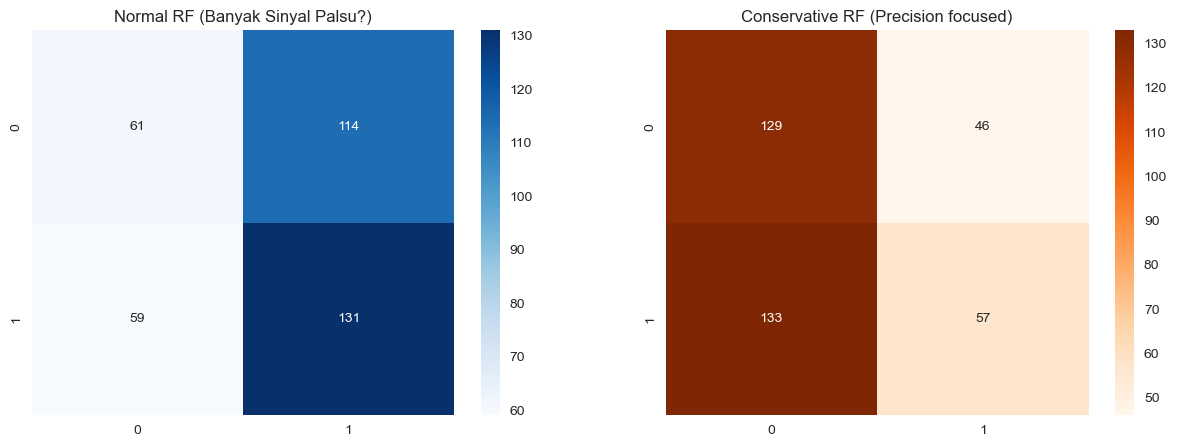

In [4]:
def show_metrics(model, name):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    tp = cm[1,1]
    fp = cm[0,1]
    precision = precision_score(y_test, preds)
    
    print(f"\n--- {name} ---")
    print(f"Prediksi 1, Aktual 1 (TP): {tp} (Keuntungan)")
    print(f"Prediksi 1, Aktual 0 (FP): {fp} (Sinyal Palsu)")
    print(f"Precision (Akurasi Sinyal Beli): {precision:.2%}")
    return cm

cm_normal = show_metrics(model_normal, "Model Normal")
cm_cons = show_metrics(model_conservative, "Model Konservatif (Weighted)")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm_normal, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Normal RF (Banyak Sinyal Palsu?)")
sns.heatmap(cm_cons, annot=True, fmt='d', cmap='Oranges', ax=ax[1])
ax[1].set_title("Conservative RF (Precision focused)")
plt.show()

## 💡 Mengapa strategi ini sangat 'Thesis-Friendly'?

1. **Risk Management**: Anda membuktikan bahwa dalam algoritma finansial, **Precision lebih berharga daripada Accuracy**. Lebih baik tidak trading (miss opportunity) daripada trading lalu rugi (false signal).
2. **Asymmetric Cost**: Anda menjelaskan secara akademis bahwa biaya kesalahan prediksi Bullish (investasi gagal) jauh lebih tinggi daripada biaya kesalahan prediksi Bearish (kehilangan peluang untung).
3. **Practical Utility**: Hasil model Konservatif ini akan membuat kurva ekuitas Markowitz Anda menjadi lebih mulus karena jarang terkena *whipsaw*.